## Imports

In [11]:
import tensorflow as tf
import numpy as np
from pathlib import Path
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from keras.datasets import mnist
from tensorflow.python.keras.utils.layer_utils import count_params
from keras import utils, models, layers

## Helper functions

In [12]:
# FLOP computation from: https://github.com/tensorflow/tensorflow/issues/32809#issuecomment-1065141109
def get_flops(model):
  forward_pass = tf.function(model.call, input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:])])
  graph_info = profile(forward_pass.get_concrete_function().graph, options=ProfileOptionBuilder.float_operation())
  flops = graph_info.total_float_ops
  return flops

def get_params(model):
  trainable_count = count_params(model.trainable_weights)
  non_trainable_count = count_params(model.non_trainable_weights)
  return trainable_count + non_trainable_count

## Initialize lists

In [13]:
model_by_name = {}
params = {}
flops = {}
histories = {}
accuracies = {}

models_dir = Path(f"./models")
for model_path in models_dir.glob("*.keras"):
  if not model_path.is_file():
    raise FileNotFoundError("Could not find a file with that name.")
  name = model_path.stem
  model = models.load_model(model_path, compile=True)
  model_by_name.update({name: model})
  params.update({name: get_params(model)})
  flops.update({name: get_flops(model)})
  history_path = Path(f"./histories/{name}.npy")
  if not history_path.is_file():
    raise FileNotFoundError("Could not find file with that name.")
  history = np.load(history_path, allow_pickle=True).item()
  histories.update({name: history})
  
  results_path = Path(f"./results/{name}.npy")
  if not results_path.is_file():
    raise FileNotFoundError("Could not find file with that name.")
  results = np.load(results_path, allow_pickle=True)
  accuracies.update({name: results[1]})


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profi

## Metric calculations

In [14]:
# Raw accuracy per FLOP
accuracy_point_per_flop = {}
for name in model_by_name.keys():
  accuracy_point_per_flop.update({name: accuracies[name] / flops[name]})

# Accuracy below/above the baseline
accuracy_diff = {}
for name in model_by_name.keys():
  accuracy_diff.update({name: accuracies[name] - accuracies["Baseline"]})

# FLOPs below/above the baseline 
flops_ratio = {}
for name in model_by_name.keys():
  flops_ratio.update({name: flops[name] / flops["Baseline"] - 1})

# Accuracy below/above the baseline, per FLOP
accuracy_diff_per_flop = {}
for name in model_by_name.keys():
  accuracy_diff_per_flop.update({name: accuracy_diff[name] / flops[name]})

## Graphing the results

/var/folders/wl/mkq9j9bn1ln21zzjvvy_v2km0000gn/T/ipykernel_6060/1460621555.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax7.set_xticklabels([-0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5])


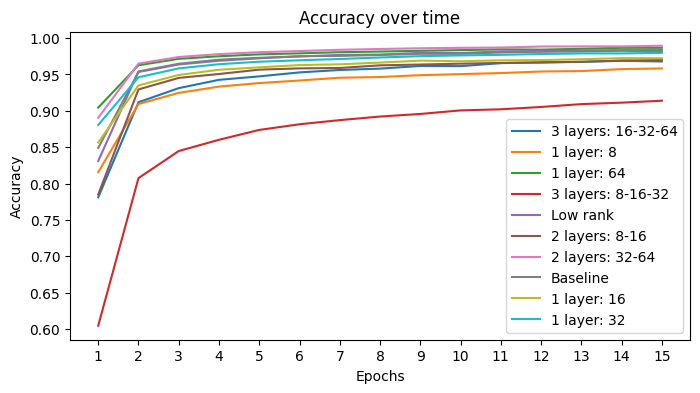

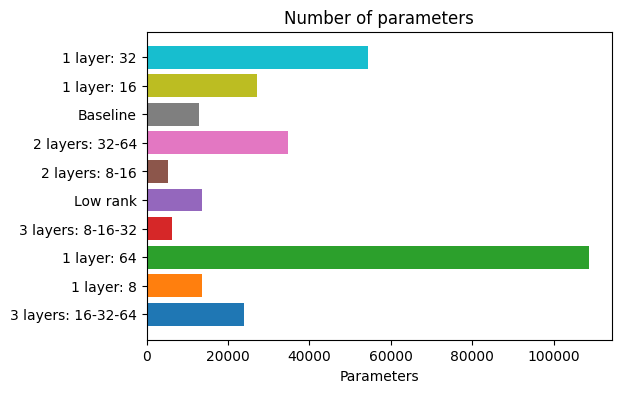

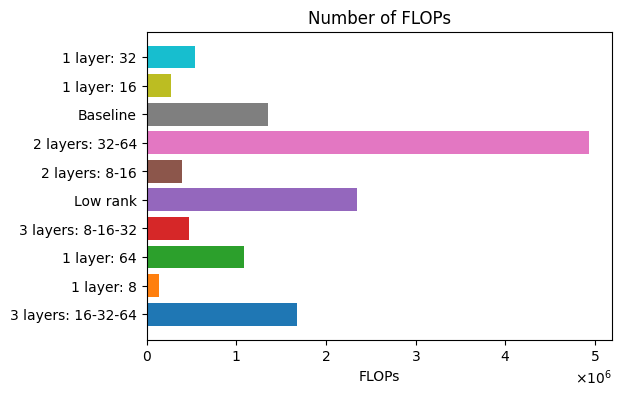

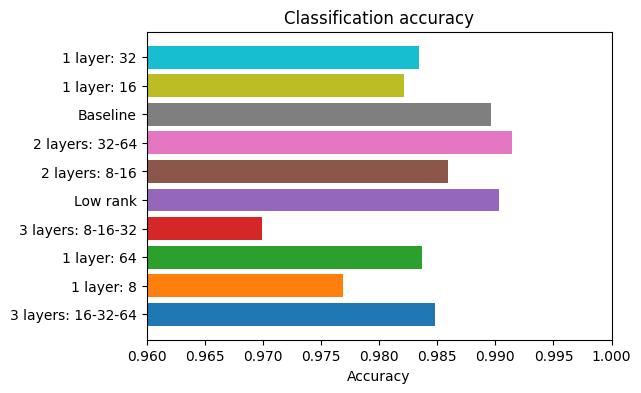

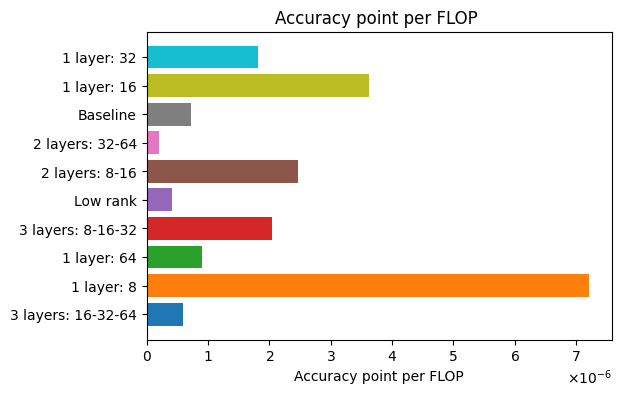

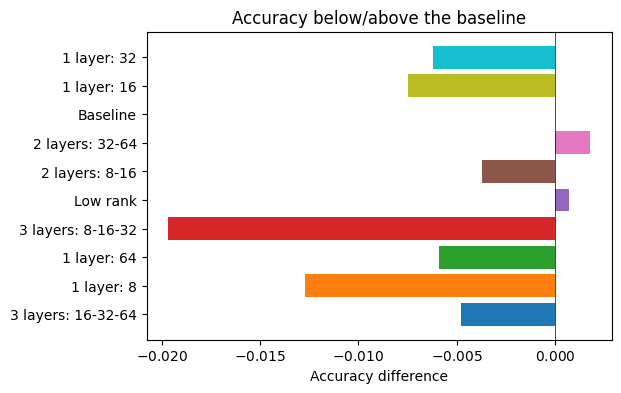

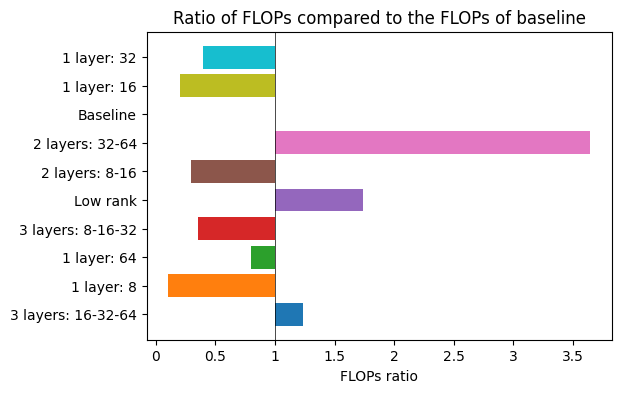

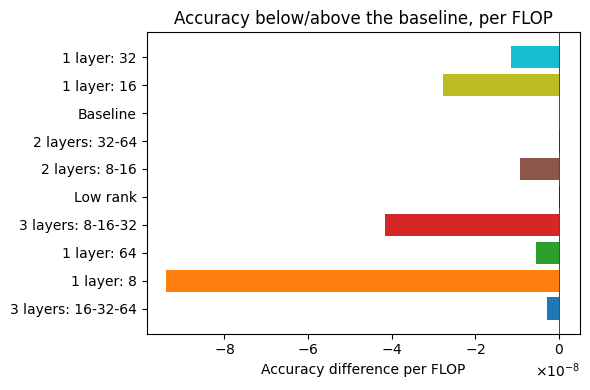

In [15]:
names = model_by_name.keys()

fig1, ax1 = plt.subplots(1)
fig1.set_size_inches((8, 4))

for name in names:
  ax1.plot(range(1, 16), (histories[name])['accuracy'], label=name)
ax1.legend(loc="lower right")
ax1.set_xlabel("Epochs")
ax1.set_xticks(ticks=range(1, 16), labels=range(1, 16))
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy over time")

fig2, ax2 = plt.subplots(1)
fig2.set_size_inches((6, 4))

for name in names:
  ax2.barh(name, params[name])
ax2.set_xlabel("Parameters")
ax2.set_title("Number of parameters")

fig3, ax3 = plt.subplots(1)
fig3.set_size_inches((6,4))

for name in names:
  ax3.barh(name, flops[name])
ax3.set_xlabel("FLOPs")
ax3.set_title("Number of FLOPs")
ax3.ticklabel_format(axis='x', useMathText=True)

fig4, ax4 = plt.subplots(1)
fig4.set_size_inches((6, 4))

for name in names:
  ax4.barh(name, accuracies[name])
ax4.set_xlabel("Accuracy")
ax4.set_title("Classification accuracy")
ax4.set_xlim([0.96, 1.0])
ax4.xaxis.set_major_formatter(FormatStrFormatter("%.3f"))

fig5, ax5 = plt.subplots(1)
fig5.set_size_inches((6, 4))

for name in names:
  ax5.barh(name, accuracy_point_per_flop[name])
ax5.set_xlabel("Accuracy point per FLOP")
ax5.set_title("Accuracy point per FLOP ")
ax5.ticklabel_format(axis='x', useMathText=True)

fig6, ax6 = plt.subplots(1)
fig6.set_size_inches((6, 4))

for name in names:
  ax6.barh(name, accuracy_diff[name])
ax6.set_xlabel("Accuracy difference")
ax6.set_title("Accuracy below/above the baseline")
ax6.ticklabel_format(axis='x', useMathText=True)
ax6.axvline(x=0, linewidth=0.5, color='k')

fig7, ax7 = plt.subplots(1)
fig7.set_size_inches((6, 4))

for name in names:
  ax7.barh(name, flops_ratio[name])
ax7.set_xlabel("FLOPs ratio")
ax7.set_title("Ratio of FLOPs compared to the FLOPs of baseline")
ax7.ticklabel_format(axis='x', useMathText=True)
ax7.set_xticklabels([-0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5])
ax7.axvline(x=0, linewidth=0.5, color='k')

fig8, ax8 = plt.subplots(1)
fig8.set_size_inches((6, 4))

for name in names:
  ax8.barh(name, accuracy_diff_per_flop[name])
ax8.set_xlabel("Accuracy difference per FLOP")
ax8.set_title("Accuracy below/above the baseline, per FLOP")
ax8.ticklabel_format(axis='x', useMathText=True)
ax8.axvline(x=0, linewidth=0.5, color='k')

plt.tight_layout()
plt.show()